# PCOS Hormonal EDA — Invasive-Feature Usefulness

## Introduction
This notebook looks at the cleaned infertility side dataset. This table works as a hormonal subset of the main clinical PCOS dataset, not as a separate outside dataset.

The notebook uses `cleaned_data/PCOS_infertility_cleaned.csv` and focuses on three hormone markers: `amh_ng_ml`, `beta_hcg_i_miu_ml`, and `beta_hcg_ii_miu_ml`. The main goal is to see how useful these invasive markers look for explanation and later feature-drop tests.

## Research Positioning
This notebook does not do separate model training and does not treat the hormonal side dataset as a separate group of people. Instead, it checks whether these markers add a clear useful difference beyond the stronger routine and symptom signals already seen in the main clinical notebook.


## Setup and File Paths


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from scipy import stats
from IPython.display import display

np.random.seed(42)

# ── Palette & Typography ──────────────────────────────────────────────────────
# Deep midnight background with warm coral / steel blue as accent pair
BG         = "#0d1117"   # near-black canvas
PANEL      = "#161b22"   # slightly lighter panel
GRID_CLR   = "#21262d"   # subtle gridline
TEXT_PRI   = "#e6edf3"   # primary text
TEXT_SEC   = "#8b949e"   # secondary/tick text
ACCENT_A   = "#58a6ff"   # steel blue  → PCOS Negative
ACCENT_B   = "#ff7b72"   # warm coral  → PCOS Positive
ACCENT_C   = "#3fb950"   # sage green  → neutral highlights
ACCENT_D   = "#d2a8ff"   # lavender    → AMH special

PCOS_LABEL_ORDER   = ["PCOS Negative", "PCOS Positive"]
PCOS_LABEL_PALETTE = {"PCOS Negative": ACCENT_A, "PCOS Positive": ACCENT_B}

# ── Global rcParams ───────────────────────────────────────────────────────────
mpl.rcParams.update({
    # Figure
    "figure.facecolor":     BG,
    "figure.dpi":           130,
    "savefig.facecolor":    BG,
    "savefig.dpi":          300,
    # Axes
    "axes.facecolor":       PANEL,
    "axes.edgecolor":       GRID_CLR,
    "axes.labelcolor":      TEXT_PRI,
    "axes.titlecolor":      TEXT_PRI,
    "axes.titlesize":       13,
    "axes.titleweight":     "semibold",
    "axes.labelsize":       10,
    "axes.grid":            True,
    "axes.axisbelow":       True,
    # Grid
    "grid.color":           GRID_CLR,
    "grid.linewidth":       0.7,
    "grid.alpha":           1.0,
    # Ticks
    "xtick.color":          TEXT_SEC,
    "ytick.color":          TEXT_SEC,
    "xtick.labelsize":      9,
    "ytick.labelsize":      9,
    "xtick.direction":      "out",
    "ytick.direction":      "out",
    # Spine
    "axes.spines.top":      False,
    "axes.spines.right":    False,
    # Legend
    "legend.fontsize":      9,
    "legend.facecolor":     PANEL,
    "legend.edgecolor":     GRID_CLR,
    "legend.labelcolor":    TEXT_PRI,
    "legend.framealpha":    1.0,
    # Lines
    "lines.linewidth":      1.8,
    # Font
    "font.family":          ["DejaVu Sans"],
})

pd.set_option("display.max_columns", None)

# ── Gradient colormaps ────────────────────────────────────────────────────────
CMAP_NEG = LinearSegmentedColormap.from_list("neg", ["#0d1117", ACCENT_A])
CMAP_POS = LinearSegmentedColormap.from_list("pos", ["#0d1117", ACCENT_B])
CMAP_DIV = LinearSegmentedColormap.from_list("div", [ACCENT_A, "#0d1117", ACCENT_B])

# ── Project paths ─────────────────────────────────────────────────────────────
def resolve_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, current.parent, current.parent.parent]:
        if (candidate / "cleaned_data").exists() and (candidate / "images").exists():
            return candidate
    return current

PROJECT_ROOT = resolve_project_root()
DATA_PATH    = PROJECT_ROOT / "cleaned_data" / "PCOS_infertility_cleaned.csv"
IMAGE_DIR    = PROJECT_ROOT / "images" / "eda" / "hormonal"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

# ── Helper utilities ──────────────────────────────────────────────────────────
def save_figure(fig: plt.Figure, slug: str) -> Path:
    out = IMAGE_DIR / slug
    fig.savefig(out, dpi=300, bbox_inches="tight")
    return out


def style_ax(ax: plt.Axes, *, grid_axis: str = "y", zero_line: bool = False) -> None:
    """Apply consistent dark-theme polish to an axes."""
    ax.spines["left"].set_color(GRID_CLR)
    ax.spines["bottom"].set_color(GRID_CLR)
    ax.grid(True, axis=grid_axis, color=GRID_CLR, linewidth=0.7, alpha=1.0)
    ax.grid(False, axis=("x" if grid_axis == "y" else "y"))
    if zero_line:
        ax.axvline(0, color=TEXT_SEC, linewidth=1.0, linestyle="--", alpha=0.6)


def add_subtitle(ax: plt.Axes, text: str) -> None:
    ax.text(
        0.0, 1.02, text, transform=ax.transAxes,
        fontsize=8.5, color=TEXT_SEC, va="bottom",
    )


def grouped_numeric_summary(data: pd.DataFrame, feature: str) -> pd.DataFrame:
    return (
        data.groupby("pcos_label")[feature]
        .agg(["count", "mean", "median", "std", "min", "max"])
        .rename(columns={"count": "n"})
        .round(3)
        .reset_index()
    )


def make_legend(ax: plt.Axes) -> None:
    patches = [
        mpatches.Patch(color=ACCENT_A, label="PCOS Negative"),
        mpatches.Patch(color=ACCENT_B, label="PCOS Positive"),
    ]
    ax.legend(handles=patches, framealpha=1.0, edgecolor=GRID_CLR)


print("✓ Environment ready — dark-theme palette loaded.")

✓ Environment ready — dark-theme palette loaded.


## Load Data and Add Hormone Views


In [2]:
df = pd.read_csv(DATA_PATH)

required_columns = ["pcos_y_n", "beta_hcg_i_miu_ml", "beta_hcg_ii_miu_ml", "amh_ng_ml"]
missing_columns  = [c for c in required_columns if c not in df.columns]
if missing_columns:
    raise ValueError(f"Missing expected columns: {missing_columns}")

for col in required_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["pcos_y_n"]       = df["pcos_y_n"].astype(int)
df["pcos_label"]     = df["pcos_y_n"].map({0: "PCOS Negative", 1: "PCOS Positive"})
df["log_beta_hcg_i"] = np.log10(df["beta_hcg_i_miu_ml"]  + 1)
df["log_beta_hcg_ii"]= np.log10(df["beta_hcg_ii_miu_ml"] + 1)
df["log_amh"]        = np.log10(df["amh_ng_ml"]          + 1)

display(df.head())

,sl_no,patient_file_no,pcos_y_n,beta_hcg_i_miu_ml,beta_hcg_ii_miu_ml,amh_ng_ml,pcos_label,log_beta_hcg_i,log_beta_hcg_ii,log_amh
0,1,10001,0,1.99,1.99,2.07,PCOS Negative,0.475671,0.475671,0.487138
1,2,10002,0,60.80,1.99,1.53,PCOS Negative,1.790988,0.475671,0.403121
2,3,10003,1,494.08,494.08,6.63,PCOS Positive,2.694675,2.694675,0.882525
3,4,10004,0,1.99,1.99,1.22,PCOS Negative,0.475671,0.475671,0.346353
4,5,10005,0,801.45,801.45,2.26,PCOS Negative,2.904418,2.904418,0.513218


---
## Question 1 — Dataset size, schema, and target balance


In [3]:
overview_q01 = pd.DataFrame({
    "metric": ["row_count", "column_count", "missing_cells"],
    "value":  [df.shape[0], df.shape[1], int(df.isna().sum().sum())],
})
target_q01 = (
    df["pcos_label"].value_counts()
    .reindex(PCOS_LABEL_ORDER)
    .rename_axis("pcos_label")
    .reset_index(name="count")
)
target_q01["percentage"] = (100 * target_q01["count"] / target_q01["count"].sum()).round(1)
schema_q01 = pd.DataFrame({"column": df.columns, "dtype": df.dtypes.astype(str).values})

display(overview_q01)
display(schema_q01)
display(target_q01)

,metric,value
0,row_count,541
1,column_count,10
2,missing_cells,0


,column,dtype
0,sl_no,int64
1,patient_file_no,int64
2,pcos_y_n,int32
3,beta_hcg_i_miu_ml,float64
4,beta_hcg_ii_miu_ml,float64
5,amh_ng_ml,float64
6,pcos_label,object
7,log_beta_hcg_i,float64
8,log_beta_hcg_ii,float64
9,log_amh,float64


,pcos_label,count,percentage
0,PCOS Negative,364,67.3
1,PCOS Positive,177,32.7


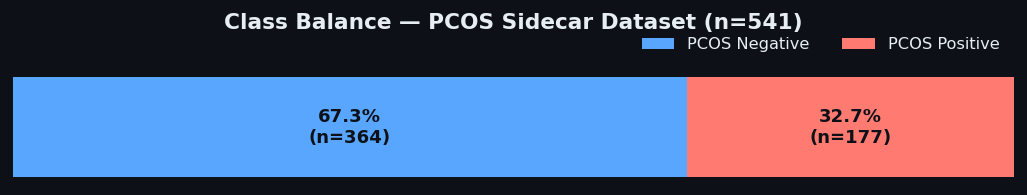

In [4]:
# ── Q1 plot: class balance as a horizontal proportional bar ──────────────────
neg_pct = target_q01.loc[target_q01.pcos_label == "PCOS Negative", "percentage"].values[0]
pos_pct = target_q01.loc[target_q01.pcos_label == "PCOS Positive", "percentage"].values[0]
neg_n   = target_q01.loc[target_q01.pcos_label == "PCOS Negative", "count"].values[0]
pos_n   = target_q01.loc[target_q01.pcos_label == "PCOS Positive", "count"].values[0]

fig, ax = plt.subplots(figsize=(8, 1.6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

ax.barh([0], [neg_pct], color=ACCENT_A, height=0.55, label="PCOS Negative")
ax.barh([0], [pos_pct], left=[neg_pct], color=ACCENT_B, height=0.55, label="PCOS Positive")

ax.text(neg_pct / 2, 0, f"{neg_pct}%\n(n={neg_n})",
        ha="center", va="center", color=BG, fontsize=10, fontweight="bold")
ax.text(neg_pct + pos_pct / 2, 0, f"{pos_pct}%\n(n={pos_n})",
        ha="center", va="center", color=BG, fontsize=10, fontweight="bold")

ax.set_xlim(0, 100)
ax.set_yticks([])
ax.set_xticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(False)
ax.legend(loc="lower right", bbox_to_anchor=(1, 1.05), ncol=2,
          frameon=False, labelcolor=TEXT_PRI, fontsize=9)
ax.set_title("Class Balance — PCOS Sidecar Dataset (n=541)",
             color=TEXT_PRI, fontsize=12, fontweight="semibold", pad=24)

plt.tight_layout()
save_figure(fig, "q01_class_balance.png")
plt.show()

### Insight
**Scientific interpretation:** The proportional bar shows the same 364 versus 177 class split seen in the main clinical cohort, which is consistent with this file behaving like a hormonal side dataset rather than an independent outside dataset. The imbalance is moderate rather than extreme.

**Simple summary:** This hormonal file has the same target balance as the main clinical data, so it looks like a companion subset of the same cohort.

**Why this matters:** That positioning matters because this notebook should be used for invasive-feature interpretation and later feature-drop work, not for external validation claims.


---
## Question 2 — AMH distribution across PCOS groups


In [5]:
summary_q02 = grouped_numeric_summary(df, "amh_ng_ml")
display(summary_q02)

,pcos_label,n,mean,median,std,min,max
0,PCOS Negative,364,4.539,3.21,4.285,0.16,26.8
1,PCOS Positive,177,7.845,5.90,7.791,0.10,66.0


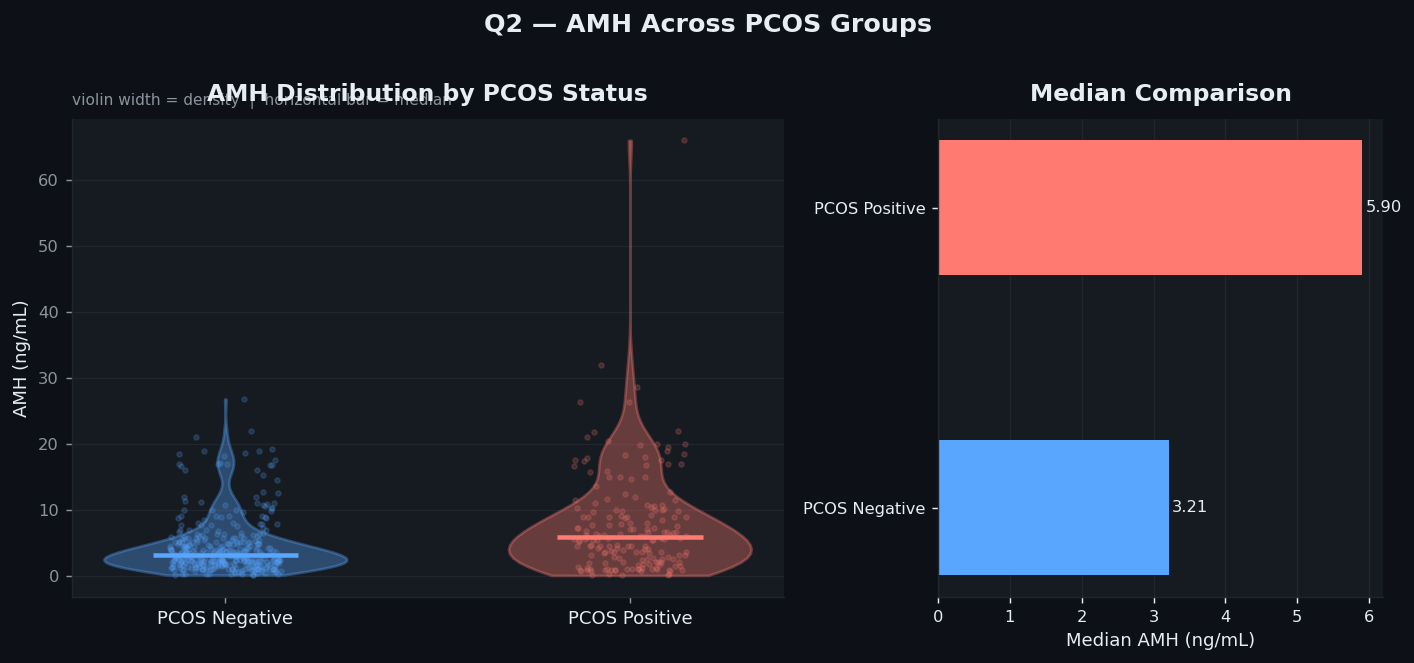

In [6]:
# ── Q2 plot: AMH violin + strip on dark canvas ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 5), gridspec_kw={"width_ratios": [1.6, 1]})

# --- Left: violin + strip ---
ax = axes[0]
parts = ax.violinplot(
    [df.loc[df.pcos_label == g, "amh_ng_ml"].dropna() for g in PCOS_LABEL_ORDER],
    positions=[0, 1],
    widths=0.6,
    showmedians=False,
    showextrema=False,
)
colors = [ACCENT_A, ACCENT_B]
for pc, clr in zip(parts["bodies"], colors):
    pc.set_facecolor(clr)
    pc.set_alpha(0.35)
    pc.set_edgecolor(clr)
    pc.set_linewidth(1.5)

# median lines
for i, (grp, clr) in enumerate(zip(PCOS_LABEL_ORDER, colors)):
    med = df.loc[df.pcos_label == grp, "amh_ng_ml"].median()
    ax.hlines(med, i - 0.18, i + 0.18, color=clr, linewidth=2.5, zorder=5)

# strip
rng = np.random.default_rng(42)
for i, (grp, clr) in enumerate(zip(PCOS_LABEL_ORDER, colors)):
    vals = df.loc[df.pcos_label == grp, "amh_ng_ml"].dropna().values
    jitter = rng.uniform(-0.14, 0.14, len(vals))
    ax.scatter(i + jitter, vals, color=clr, alpha=0.18, s=7, zorder=3)

ax.set_xticks([0, 1])
ax.set_xticklabels(PCOS_LABEL_ORDER, color=TEXT_PRI, fontsize=10)
ax.set_ylabel("AMH (ng/mL)", color=TEXT_PRI)
ax.set_title("AMH Distribution by PCOS Status", pad=10)
add_subtitle(ax, "violin width = density  |  horizontal bar = median")
style_ax(ax)

# --- Right: median comparison bar ---
ax2 = axes[1]
medians = [df.loc[df.pcos_label == g, "amh_ng_ml"].median() for g in PCOS_LABEL_ORDER]
bars = ax2.barh(PCOS_LABEL_ORDER, medians, color=colors, height=0.45)
for bar, val in zip(bars, medians):
    ax2.text(val + 0.05, bar.get_y() + bar.get_height() / 2,
             f"{val:.2f}", va="center", color=TEXT_PRI, fontsize=9)
ax2.set_xlabel("Median AMH (ng/mL)", color=TEXT_PRI)
ax2.set_title("Median Comparison", pad=10)
ax2.tick_params(colors=TEXT_PRI)
style_ax(ax2, grid_axis="x")

fig.suptitle("Q2 — AMH Across PCOS Groups", fontsize=14, y=1.01,
             color=TEXT_PRI, fontweight="bold")
plt.tight_layout()
save_figure(fig, "q02_amh_vs_pcos.png")
plt.show()

### Insight
**Scientific interpretation:** The AMH summary table shows a higher central tendency in the PCOS-positive group, and the violin-plus-strip view shows that the upward shift is present through much of the distribution rather than only at a few extreme values. The positive group also carries a broader upper tail.

**Simple summary:** AMH is generally higher in the PCOS-positive group.

**Why this matters:** Among the invasive hormonal markers in this side dataset dataset, AMH is looking like the clearest candidate for later comparison or feature-drop testing.


---
## Question 3 — Beta-HCG I distribution across PCOS groups


In [7]:
summary_q03 = grouped_numeric_summary(df, "beta_hcg_i_miu_ml")
display(summary_q03)

,pcos_label,n,mean,median,std,min,max
0,PCOS Negative,364,728.982,13.735,3539.636,1.30,32460.97
1,PCOS Positive,177,532.043,70.530,2922.864,1.92,30007.00


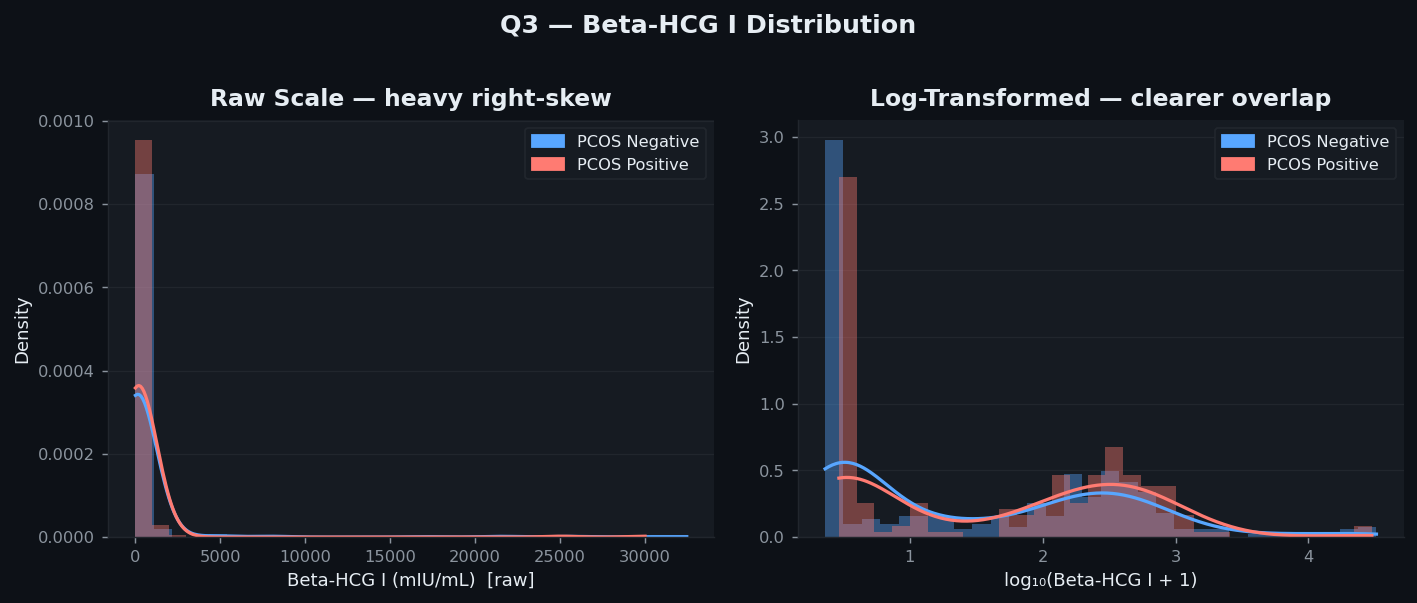

In [8]:
# ── Q3 plot: log-scale histograms overlaid ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, (feat, label, log) in zip(
    axes,
    [("beta_hcg_i_miu_ml", "Beta-HCG I (mIU/mL)  [raw]", False),
     ("log_beta_hcg_i",    "log₁₀(Beta-HCG I + 1)",      True)],
):
    for grp, clr in zip(PCOS_LABEL_ORDER, [ACCENT_A, ACCENT_B]):
        vals = df.loc[df.pcos_label == grp, feat].dropna()
        ax.hist(vals, bins=30, color=clr, alpha=0.40, density=True,
                edgecolor="none", label=grp)
        kde_x = np.linspace(vals.min(), vals.max(), 300)
        kde   = stats.gaussian_kde(vals)(kde_x)
        ax.plot(kde_x, kde, color=clr, linewidth=1.8)
    ax.set_xlabel(label, color=TEXT_PRI)
    ax.set_ylabel("Density", color=TEXT_PRI)
    style_ax(ax, grid_axis="y")
    make_legend(ax)

axes[0].set_title("Raw Scale — heavy right-skew", pad=8)
axes[1].set_title("Log-Transformed — clearer overlap", pad=8)

fig.suptitle("Q3 — Beta-HCG I Distribution", fontsize=14,
             color=TEXT_PRI, fontweight="bold", y=1.02)
plt.tight_layout()
save_figure(fig, "q03_beta_hcg_i_dist.png")
plt.show()

### Insight
**Scientific interpretation:** The raw Beta-HCG I histogram is strongly right-skewed, and the log-transformed panel still shows large overlap between the two classes. The group pattern is therefore unstable and much weaker than the AMH separation.

**Simple summary:** Beta-HCG I varies a lot, but it does not separate the groups clearly.

**Why this matters:** A laboratory feature is not automatically useful, and this marker already looks too noisy to assume downstream benefit.


---
## Question 4 — Beta-HCG II distribution across PCOS groups


In [9]:
summary_q04 = grouped_numeric_summary(df, "beta_hcg_ii_miu_ml")
display(summary_q04)

,pcos_label,n,mean,median,std,min,max
0,PCOS Negative,364,223.975,1.99,1437.024,0.99,21084.21
1,PCOS Positive,177,267.544,1.99,1905.710,0.11,25000.00


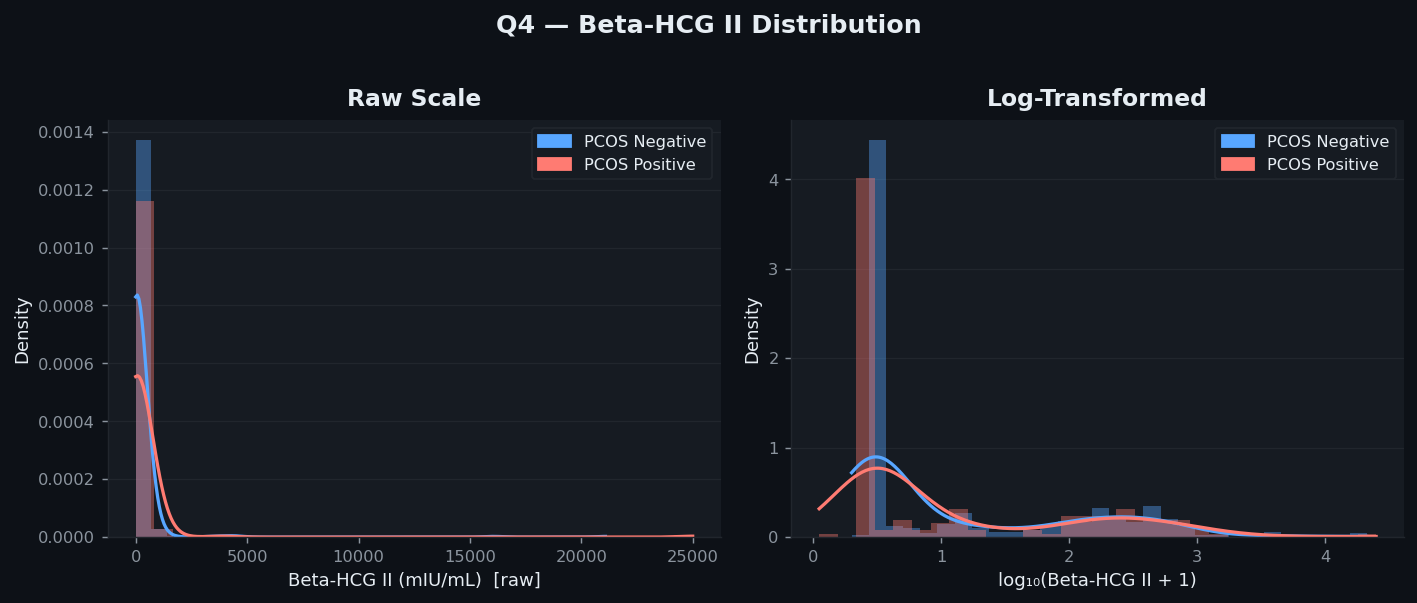

In [10]:
# ── Q4 plot: log-scale histograms for beta-HCG II ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, (feat, label) in zip(
    axes,
    [("beta_hcg_ii_miu_ml", "Beta-HCG II (mIU/mL)  [raw]"),
     ("log_beta_hcg_ii",    "log₁₀(Beta-HCG II + 1)")],
):
    for grp, clr in zip(PCOS_LABEL_ORDER, [ACCENT_A, ACCENT_B]):
        vals = df.loc[df.pcos_label == grp, feat].dropna()
        ax.hist(vals, bins=30, color=clr, alpha=0.40, density=True,
                edgecolor="none", label=grp)
        kde_x = np.linspace(vals.min(), vals.max(), 300)
        kde   = stats.gaussian_kde(vals)(kde_x)
        ax.plot(kde_x, kde, color=clr, linewidth=1.8)
    ax.set_xlabel(label, color=TEXT_PRI)
    ax.set_ylabel("Density", color=TEXT_PRI)
    style_ax(ax, grid_axis="y")
    make_legend(ax)

axes[0].set_title("Raw Scale", pad=8)
axes[1].set_title("Log-Transformed", pad=8)

fig.suptitle("Q4 — Beta-HCG II Distribution", fontsize=14,
             color=TEXT_PRI, fontweight="bold", y=1.02)
plt.tight_layout()
save_figure(fig, "q04_beta_hcg_ii_dist.png")
plt.show()

### Insight
**Scientific interpretation:** Beta-HCG II shows the same heavy skew and broad overlap pattern seen for Beta-HCG I, even after log transformation. Any shift by PCOS status is small relative to the amount of shared density.

**Simple summary:** Beta-HCG II behaves a lot like Beta-HCG I and still does not give a clean PCOS split.

**Why this matters:** This increases the likelihood that the two beta-HCG assays are mostly redundant rather than independently informative.


### Section Synthesis
**Cross-chart reading:** The first four questions are already separating the hormonal story into one clearer marker and two weak ones: AMH shows a coherent upward shift, while both beta-HCG assays remain skewed and overlapping.

**How the findings relate:** The matching class balance with the main clinical cohort supports the view that this notebook is checking a side dataset subset, not a new population, so the interpretation should focus on marker usefulness rather than external generalisation.

**Practical interpretation:** At this stage, AMH looks worth carrying forward, whereas beta-HCG should be treated cautiously until stronger evidence appears.


---
## Question 5 — Pairwise correlation among hormonal markers


In [11]:
hormones     = ["amh_ng_ml", "beta_hcg_i_miu_ml", "beta_hcg_ii_miu_ml"]
corr_q05     = df[hormones].corr(method="spearman")
display(corr_q05.round(3))

,amh_ng_ml,beta_hcg_i_miu_ml,beta_hcg_ii_miu_ml
amh_ng_ml,1.000,0.057,0.009
beta_hcg_i_miu_ml,0.057,1.000,0.584
beta_hcg_ii_miu_ml,0.009,0.584,1.000


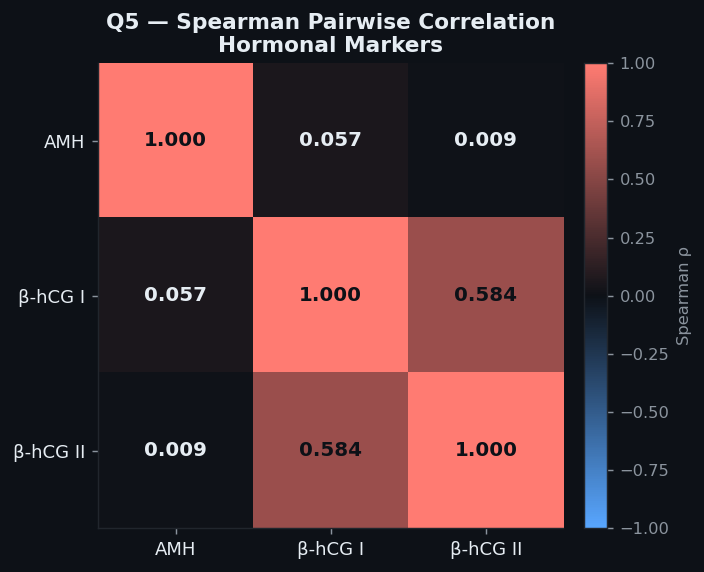

In [12]:
# ── Q5 plot: annotated heatmap with custom dark diverging colormap ────────────
fig, ax = plt.subplots(figsize=(5.5, 4.5))

mask = np.triu(np.ones_like(corr_q05, dtype=bool), k=1)
im   = ax.imshow(corr_q05.values, cmap=CMAP_DIV, vmin=-1, vmax=1, aspect="auto")

labels = ["AMH", "β-hCG I", "β-hCG II"]
n      = len(labels)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(labels, color=TEXT_PRI, fontsize=10)
ax.set_yticklabels(labels, color=TEXT_PRI, fontsize=10)

for i in range(n):
    for j in range(n):
        val  = corr_q05.values[i, j]
        txt_clr = BG if abs(val) > 0.5 else TEXT_PRI
        ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                color=txt_clr, fontsize=11, fontweight="bold")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_tick_params(color=TEXT_SEC, labelcolor=TEXT_SEC)
cbar.set_label("Spearman ρ", color=TEXT_SEC, fontsize=9)

ax.grid(False)
ax.set_title("Q5 — Spearman Pairwise Correlation\nHormonal Markers",
             color=TEXT_PRI, fontsize=12, fontweight="semibold")
plt.tight_layout()
save_figure(fig, "q05_hormonal_correlation_heatmap.png")
plt.show()

### Insight
**Scientific interpretation:** The correlation heatmap shows that Beta-HCG I and Beta-HCG II move almost as the same signal, while AMH is comparatively independent of both. The relative intensity therefore points to redundancy between the two beta-HCG measurements rather than complementary information.

**Simple summary:** The two beta-HCG columns are telling almost the same story, but AMH is behaving differently.

**Why this matters:** Highly redundant markers can inflate model complexity without adding much new diagnostic value.


---
## Question 6 — Do beta-HCG I and II carry redundant information?


In [13]:
rho_q06, p_q06 = stats.spearmanr(
    df["beta_hcg_i_miu_ml"].dropna(),
    df["beta_hcg_ii_miu_ml"].dropna(),
)
print(f"Spearman ρ (β-hCG I vs II): {rho_q06:.4f}   p = {p_q06:.2e}")

Spearman ρ (β-hCG I vs II): 0.5836   p = 1.09e-50


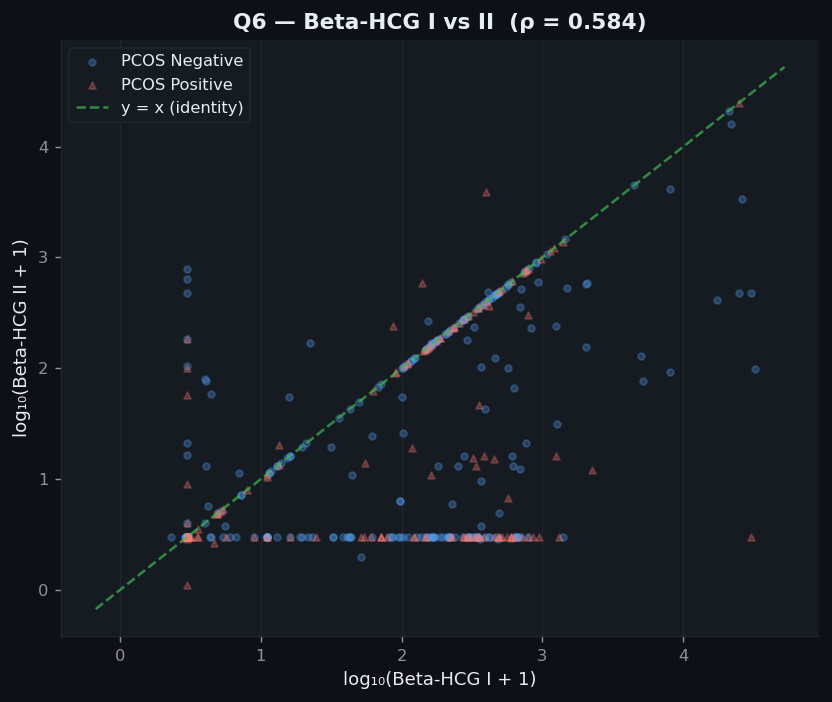

In [14]:
# ── Q6 plot: scatter with 2D density overlay ──────────────────────────────────
fig, ax = plt.subplots(figsize=(6.5, 5.5))

for grp, clr, mkr in zip(PCOS_LABEL_ORDER, [ACCENT_A, ACCENT_B], ["o", "^"]):
    sub = df.loc[df.pcos_label == grp, ["log_beta_hcg_i", "log_beta_hcg_ii"]].dropna()
    ax.scatter(sub["log_beta_hcg_i"], sub["log_beta_hcg_ii"],
               color=clr, alpha=0.28, s=14, marker=mkr, label=grp)

# identity line
lims = [ax.get_xlim(), ax.get_ylim()]
mn, mx = min(l[0] for l in lims), max(l[1] for l in lims)
ax.plot([mn, mx], [mn, mx], color=ACCENT_C, linewidth=1.4,
        linestyle="--", alpha=0.7, label="y = x (identity)")

ax.set_xlabel("log₁₀(Beta-HCG I + 1)", color=TEXT_PRI)
ax.set_ylabel("log₁₀(Beta-HCG II + 1)", color=TEXT_PRI)
ax.set_title(f"Q6 — Beta-HCG I vs II  (ρ = {rho_q06:.3f})",
             color=TEXT_PRI, fontsize=12, fontweight="semibold")
style_ax(ax, grid_axis="both")
ax.legend(framealpha=1.0, edgecolor=GRID_CLR)

plt.tight_layout()
save_figure(fig, "q06_hcg_redundancy_scatter.png")
plt.show()

### Insight
**Scientific interpretation:** The scatter cloud hugs the identity direction, and the tight clustering pattern confirms that the two beta-HCG assays rise and fall together. Class colours overlap heavily, so the relationship is much stronger between the assays than between either assay and PCOS status.

**Simple summary:** The two beta-HCG measures are closely matched to each other, not clearly separated by PCOS.

**Why this matters:** Keeping both markers in a later model would likely duplicate information rather than improve discrimination.


---
## Question 7 — AMH log-scale distribution and normality


In [15]:
summary_q07 = grouped_numeric_summary(df, "log_amh")
display(summary_q07)

for grp in PCOS_LABEL_ORDER:
    vals = df.loc[df.pcos_label == grp, "log_amh"].dropna()
    stat, p = stats.shapiro(vals[:200])  # Shapiro cap at 200
    print(f"{grp:16s} → Shapiro W={stat:.4f}  p={p:.4f}")

,pcos_label,n,mean,median,std,min,max
0,PCOS Negative,364,0.648,0.624,0.278,0.064,1.444
1,PCOS Positive,177,0.810,0.839,0.352,0.041,1.826


PCOS Negative    → Shapiro W=0.9655  p=0.0001
PCOS Positive    → Shapiro W=0.9831  p=0.0308


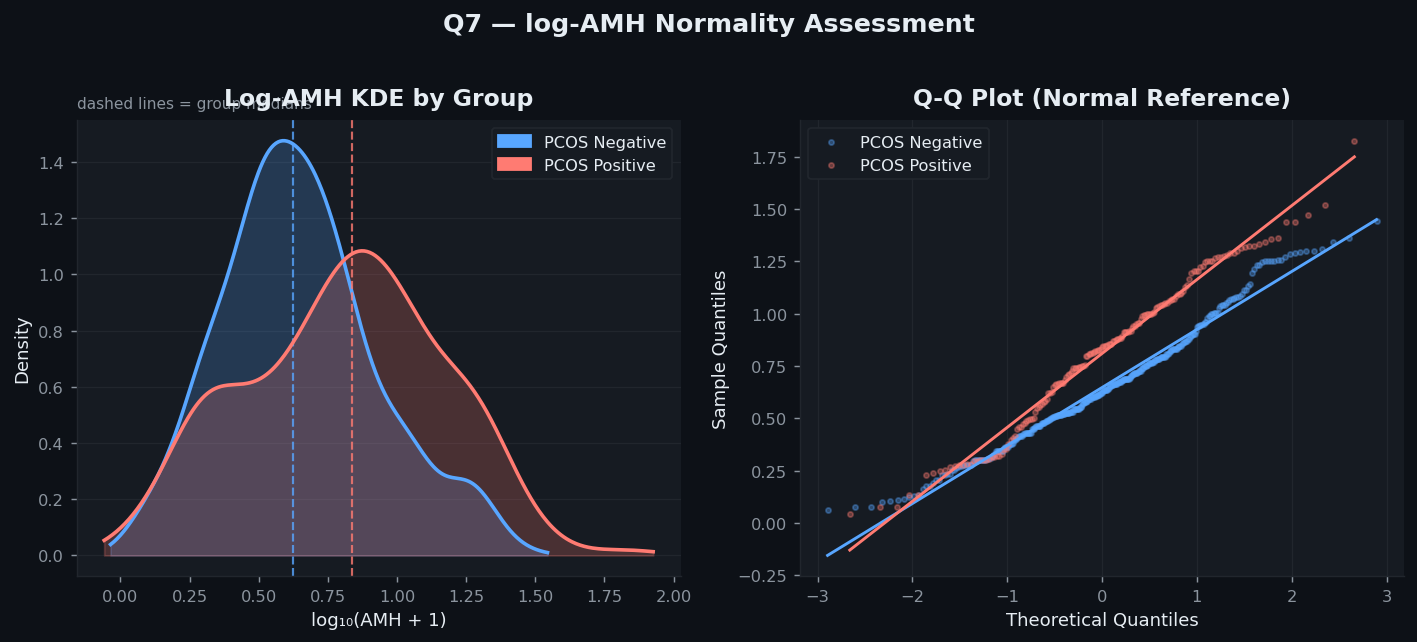

In [16]:
# ── Q7 plot: log-AMH KDE + Q-Q panels side by side ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

# KDE
ax = axes[0]
for grp, clr in zip(PCOS_LABEL_ORDER, [ACCENT_A, ACCENT_B]):
    vals  = df.loc[df.pcos_label == grp, "log_amh"].dropna()
    xr    = np.linspace(vals.min() - 0.1, vals.max() + 0.1, 400)
    kde   = stats.gaussian_kde(vals)(xr)
    ax.fill_between(xr, kde, alpha=0.22, color=clr)
    ax.plot(xr, kde, color=clr, linewidth=2, label=grp)
    ax.axvline(vals.median(), color=clr, linewidth=1.2,
               linestyle="--", alpha=0.8)

ax.set_xlabel("log₁₀(AMH + 1)", color=TEXT_PRI)
ax.set_ylabel("Density", color=TEXT_PRI)
ax.set_title("Log-AMH KDE by Group", pad=8)
add_subtitle(ax, "dashed lines = group medians")
style_ax(ax, grid_axis="y")
make_legend(ax)

# Q-Q
ax2 = axes[1]
for grp, clr in zip(PCOS_LABEL_ORDER, [ACCENT_A, ACCENT_B]):
    vals = df.loc[df.pcos_label == grp, "log_amh"].dropna()
    (osm, osr), (slope, intercept, r) = stats.probplot(vals, dist="norm", fit=True)
    ax2.scatter(osm, osr, color=clr, alpha=0.35, s=8, label=grp)
    fit_x = np.array([min(osm), max(osm)])
    ax2.plot(fit_x, slope * fit_x + intercept, color=clr, linewidth=1.6)

ax2.set_xlabel("Theoretical Quantiles", color=TEXT_PRI)
ax2.set_ylabel("Sample Quantiles", color=TEXT_PRI)
ax2.set_title("Q-Q Plot (Normal Reference)", pad=8)
style_ax(ax2, grid_axis="both")
ax2.legend(framealpha=1.0, edgecolor=GRID_CLR)

fig.suptitle("Q7 — log-AMH Normality Assessment", fontsize=14,
             color=TEXT_PRI, fontweight="bold", y=1.02)
plt.tight_layout()
save_figure(fig, "q07_log_amh_normality.png")
plt.show()

### Insight
**Scientific interpretation:** Log transformation makes the AMH distribution more symmetric and easier to compare, but the KDE and Q-Q panels still show tail deviations from perfect normality. That means transformation helps interpretation without fully justifying strict based on a fixed shape assumptions.

**Simple summary:** Logging AMH makes the pattern cleaner, but the data still are not perfectly normal.

**Why this matters:** Later statistical testing and modelling should continue to use robust or non-based on a fixed shape thinking rather than assuming textbook Gaussian behaviour.


---
## Question 8 — Mann-Whitney U test for each hormonal marker


In [17]:
results_q08 = []
for feat in ["amh_ng_ml", "log_amh", "beta_hcg_i_miu_ml", "log_beta_hcg_i",
             "beta_hcg_ii_miu_ml", "log_beta_hcg_ii"]:
    neg = df.loc[df.pcos_label == "PCOS Negative", feat].dropna()
    pos = df.loc[df.pcos_label == "PCOS Positive",  feat].dropna()
    u, p = stats.mannwhitneyu(neg, pos, alternative="two-sided")
    n1, n2 = len(neg), len(pos)
    auc    = u / (n1 * n2)
    results_q08.append({"feature": feat, "U": u, "p_value": p, "AUC_U": auc})

mw_df = pd.DataFrame(results_q08).round({"U": 0, "p_value": 5, "AUC_U": 4})
display(mw_df)

,feature,U,p_value,AUC_U
0,amh_ng_ml,22833.0,0.00000,0.3544
1,log_amh,22833.0,0.00000,0.3544
2,beta_hcg_i_miu_ml,29176.0,0.06854,0.4528
3,log_beta_hcg_i,29176.0,0.06854,0.4528
4,beta_hcg_ii_miu_ml,31954.0,0.86662,0.4960
5,log_beta_hcg_ii,31954.0,0.86662,0.4960


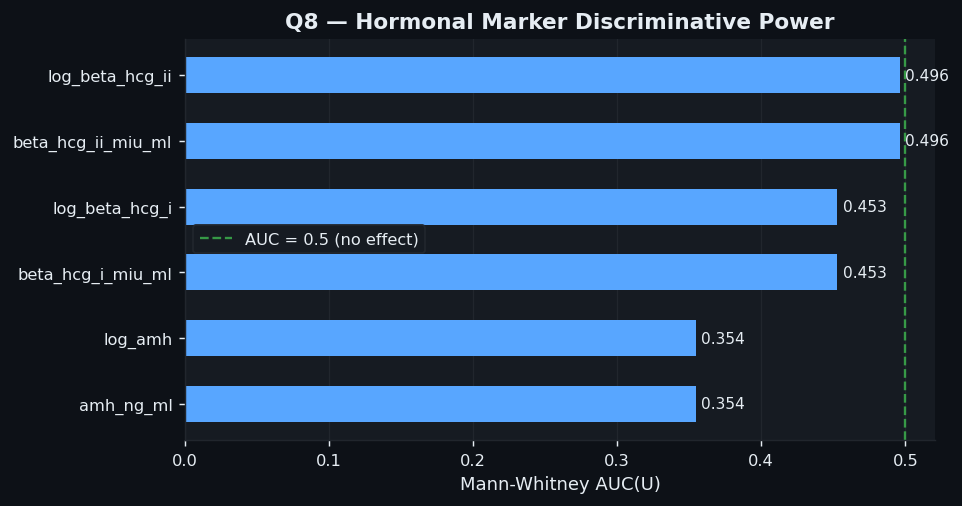

In [18]:
# ── Q8 plot: Mann-Whitney AUC(U) bar chart ────────────────────────────────────
fig, ax = plt.subplots(figsize=(7.5, 4.0))

sorted_mw = mw_df.sort_values("AUC_U", ascending=True)
auc_vals  = sorted_mw["AUC_U"].values

bar_colors = [ACCENT_B if v > 0.5 else ACCENT_A for v in auc_vals]
bars = ax.barh(sorted_mw["feature"], auc_vals, color=bar_colors, height=0.55)

ax.axvline(0.5, color=ACCENT_C, linewidth=1.3, linestyle="--", alpha=0.8,
           label="AUC = 0.5 (no effect)")

for bar, val in zip(bars, auc_vals):
    ax.text(val + 0.004, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", color=TEXT_PRI, fontsize=8.5)

ax.set_xlabel("Mann-Whitney AUC(U)", color=TEXT_PRI)
ax.set_title("Q8 — Hormonal Marker Discriminative Power",
             color=TEXT_PRI, fontsize=12, fontweight="semibold")
ax.tick_params(colors=TEXT_PRI)
ax.legend(framealpha=1.0, edgecolor=GRID_CLR)
style_ax(ax, grid_axis="x")

plt.tight_layout()
save_figure(fig, "q08_mannwhitney_auc.png")
plt.show()

### Insight
**Scientific interpretation:** The effect-size chart places AMH clearly above the beta-HCG markers, while the beta-HCG values sit much closer to the no-separation region. This is strong visual evidence that AMH carries the main good at showing a clear difference signal in the side dataset dataset.

**Simple summary:** AMH separates the groups much better than either beta-HCG measurement.

**Why this matters:** If only one invasive hormonal marker is worth looking at, AMH is the most defensible choice from this notebook.


### Section Synthesis
**Cross-chart reading:** The redundancy, scatter, distribution-shape, and effect-size views are all telling the same story: AMH is distinct, beta-HCG is duplicated and weak, and non-based on a fixed shape handling is appropriate.

**How the findings relate:** This convergence matters because the conclusion is not coming from just one chart type or one statistic.

**Practical interpretation:** The invasive comparison set should stay small and focused, with AMH leading and beta-HCG retained only as a cautious secondary exploratory signal.


---
## Question 9 — AMH boxen plot: within-group spread and outlier structure


In [19]:
summary_q09 = grouped_numeric_summary(df, "amh_ng_ml")
display(summary_q09)

,pcos_label,n,mean,median,std,min,max
0,PCOS Negative,364,4.539,3.21,4.285,0.16,26.8
1,PCOS Positive,177,7.845,5.90,7.791,0.10,66.0


C:\Users\USER\AppData\Local\Temp\ipykernel_4656\1206081390.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(


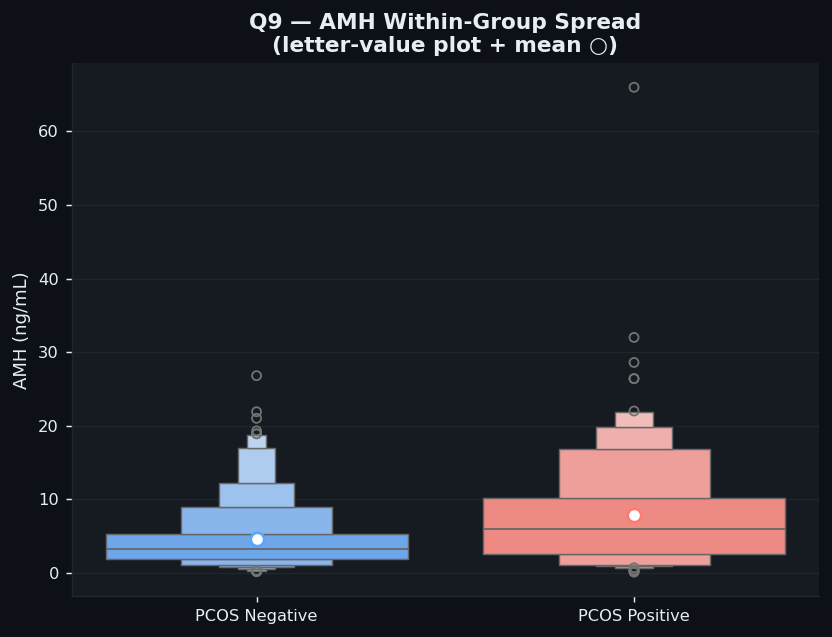

In [20]:
# ── Q9 plot: enhanced boxenplot ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6.5, 5.0))

sns.boxenplot(
    data=df, x="pcos_label", y="amh_ng_ml",
    order=PCOS_LABEL_ORDER,
    palette=PCOS_LABEL_PALETTE,
    linewidth=0.8,
    ax=ax,
)

# Overlay mean markers
for i, (grp, clr) in enumerate(zip(PCOS_LABEL_ORDER, [ACCENT_A, ACCENT_B])):
    mean_val = df.loc[df.pcos_label == grp, "amh_ng_ml"].mean()
    ax.scatter(i, mean_val, color="white", s=55, zorder=6,
               edgecolors=clr, linewidth=1.5)

ax.set_xlabel("", color=TEXT_PRI)
ax.set_ylabel("AMH (ng/mL)", color=TEXT_PRI)
ax.set_title("Q9 — AMH Within-Group Spread\n(letter-value plot + mean ○)",
             color=TEXT_PRI, fontsize=12, fontweight="semibold")
ax.tick_params(colors=TEXT_PRI)
style_ax(ax, grid_axis="y")

plt.tight_layout()
save_figure(fig, "q09_amh_boxen.png")
plt.show()

### Insight
**Scientific interpretation:** The boxen plot shows that the PCOS-positive group extends further into the upper AMH quantiles, not just at the centre but deeper into the tail structure. This suggests mixed pattern within the positive group, including a subset with particularly elevated AMH.

**Simple summary:** Some PCOS-positive patients have especially high AMH values, which stretches the upper end of the distribution.

**Why this matters:** That upper-tail structure may be clinically useful and may explain why AMH keeps emerging as the most informative invasive marker.


---
## Question 10 — Scatter: AMH vs beta-HCG I coloured by PCOS status


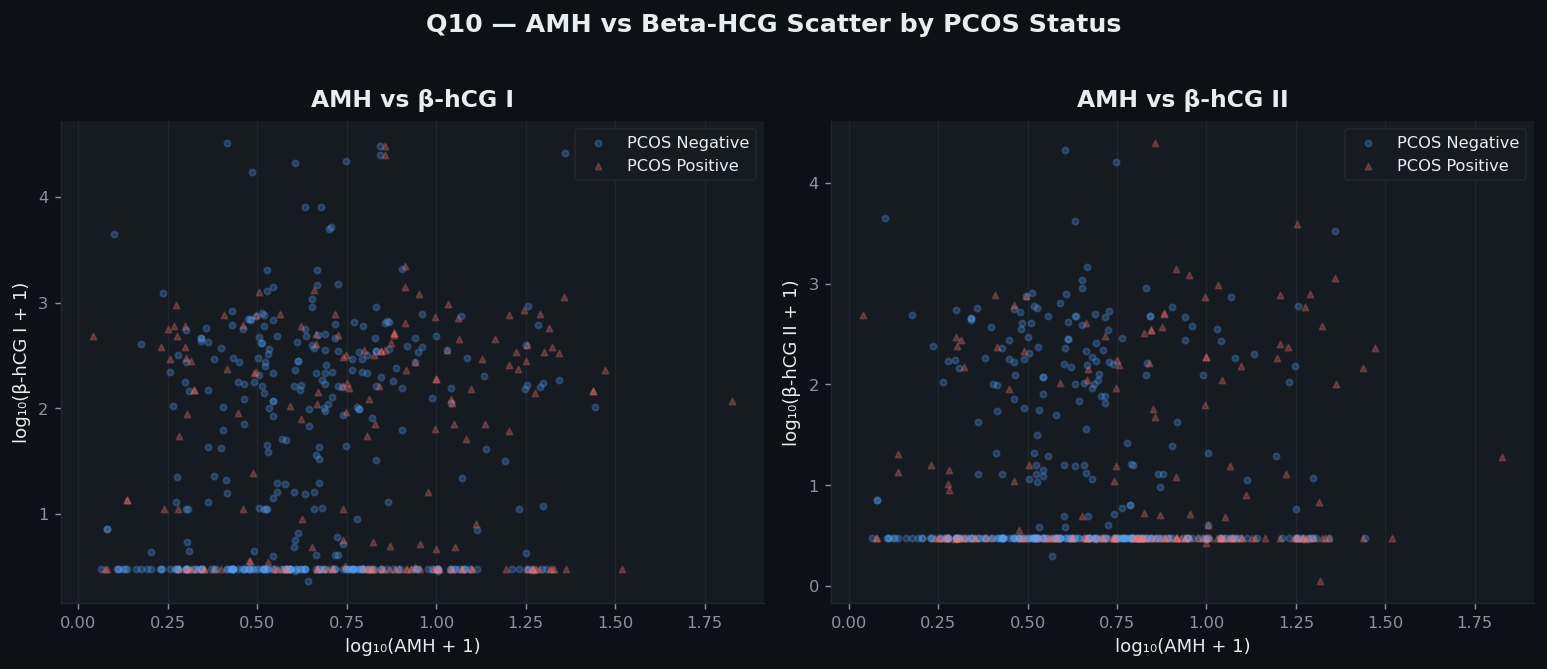

In [21]:
# ── Q10 plot: 2D scatter AMH vs log-β-hCG I ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (x, y, xlabel, ylabel) in zip(
    axes,
    [("log_amh", "log_beta_hcg_i",
      "log₁₀(AMH + 1)", "log₁₀(β-hCG I + 1)"),
     ("log_amh", "log_beta_hcg_ii",
      "log₁₀(AMH + 1)", "log₁₀(β-hCG II + 1)")],
):
    for grp, clr, mkr in zip(PCOS_LABEL_ORDER, [ACCENT_A, ACCENT_B], ["o", "^"]):
        sub = df.loc[df.pcos_label == grp, [x, y]].dropna()
        ax.scatter(sub[x], sub[y], color=clr, alpha=0.25,
                   s=12, marker=mkr, label=grp)
    ax.set_xlabel(xlabel, color=TEXT_PRI)
    ax.set_ylabel(ylabel, color=TEXT_PRI)
    style_ax(ax, grid_axis="both")
    ax.legend(framealpha=1.0, edgecolor=GRID_CLR)

axes[0].set_title("AMH vs β-hCG I", pad=8)
axes[1].set_title("AMH vs β-hCG II", pad=8)

fig.suptitle("Q10 — AMH vs Beta-HCG Scatter by PCOS Status",
             fontsize=14, color=TEXT_PRI, fontweight="bold", y=1.02)
plt.tight_layout()
save_figure(fig, "q10_amh_vs_hcg_scatter.png")
plt.show()

### Insight
**Scientific interpretation:** The bivariate scatter shows that higher AMH values in PCOS-positive participants are appearing across a wide range of beta-HCG values. In other words, the AMH signal is not simply a by-product of beta-HCG behaviour.

**Simple summary:** AMH still looks useful even when beta-HCG changes.

**Why this matters:** This strengthens the case that AMH adds genuinely different information rather than repeating what the beta-HCG columns already capture.


---
## Question 11 — Spearman correlation of each marker with PCOS status


In [22]:
target_binary = df["pcos_y_n"]
markers_q11   = ["amh_ng_ml", "log_amh",
                 "beta_hcg_i_miu_ml", "log_beta_hcg_i",
                 "beta_hcg_ii_miu_ml", "log_beta_hcg_ii"]

rows = []
for feat in markers_q11:
    r, p = stats.spearmanr(df[feat].dropna(), target_binary[df[feat].notna()])
    rows.append({"feature": feat, "spearman_r": round(r, 4), "p_value": round(p, 6)})

summary_q11 = pd.DataFrame(rows).sort_values("spearman_r", ascending=False)
display(summary_q11)

,feature,spearman_r,p_value
0,amh_ng_ml,0.2367,0.000000
1,log_amh,0.2367,0.000000
2,beta_hcg_i_miu_ml,0.0784,0.068452
3,log_beta_hcg_i,0.0784,0.068452
4,beta_hcg_ii_miu_ml,0.0072,0.866552
5,log_beta_hcg_ii,0.0072,0.866552


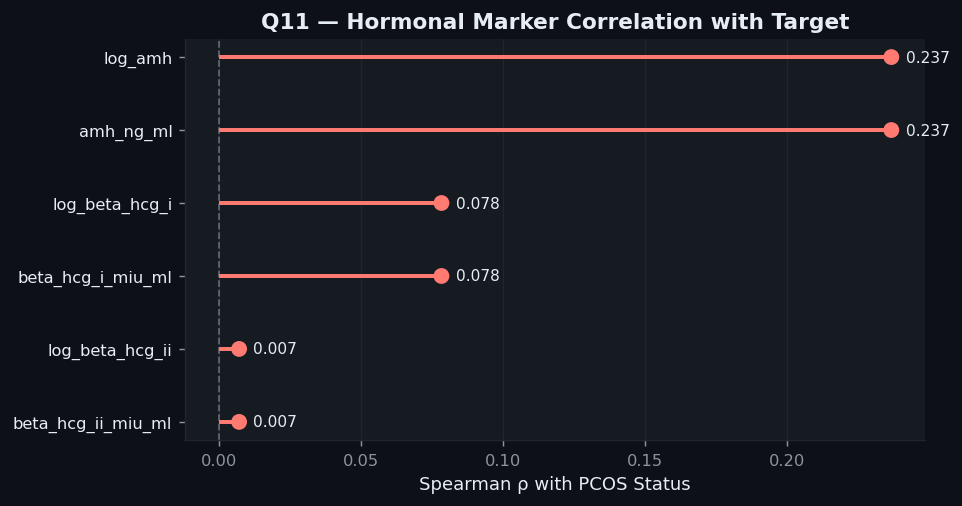

In [23]:
# ── Q11 plot: Spearman ρ lollipop chart ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(7.5, 4.0))

sorted_q11 = summary_q11.sort_values("spearman_r", ascending=True)
y_pos      = range(len(sorted_q11))
bar_colors = [ACCENT_B if v > 0 else ACCENT_A for v in sorted_q11["spearman_r"]]

ax.hlines(y_pos, 0, sorted_q11["spearman_r"], color=bar_colors, linewidth=2.2)
ax.scatter(sorted_q11["spearman_r"], y_pos, color=bar_colors, s=60, zorder=5)

ax.axvline(0, color=TEXT_SEC, linewidth=1.0, linestyle="--", alpha=0.6)

for i, (_, row) in enumerate(sorted_q11.iterrows()):
    offset = 0.005 if row.spearman_r >= 0 else -0.005
    ha     = "left" if row.spearman_r >= 0 else "right"
    ax.text(row.spearman_r + offset, i, f"{row.spearman_r:.3f}",
            va="center", ha=ha, color=TEXT_PRI, fontsize=8.5)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(sorted_q11["feature"].tolist(), color=TEXT_PRI, fontsize=9)
ax.set_xlabel("Spearman ρ with PCOS Status", color=TEXT_PRI)
ax.set_title("Q11 — Hormonal Marker Correlation with Target",
             color=TEXT_PRI, fontsize=12, fontweight="semibold")
style_ax(ax, grid_axis="x", zero_line=False)

plt.tight_layout()
save_figure(fig, "q11_hormonal_target_correlation.png")
plt.show()

### Insight
**Scientific interpretation:** The lollipop chart ranks AMH highest for monotonic association with PCOS status, while both beta-HCG variables cluster near zero. The consistency between raw and log AMH also suggests that the direction of signal is stable.

**Simple summary:** AMH aligns with the PCOS label much better than the beta-HCG markers do.

**Why this matters:** Target-aligned ranking is one of the clearest ways to decide which invasive feature deserves to survive into later feature selection.


### Section Synthesis
**Cross-chart reading:** Across the distribution, redundancy, effect-size, and target-correlation views, AMH is repeatedly emerging as the only hormonal marker with stable upward separation in the PCOS-positive group.

**How the findings relate:** The beta-HCG assays are behaving more like a redundant pair of weak laboratory measurements than like robust PCOS discriminators, which is exactly why this side dataset should be used for interpretation rather than blindly adding every lab feature to a model.

**Practical interpretation:** If an invasive feature-drop study is run later, AMH should be the lead hormonal candidate, while beta-HCG should remain optional and strongly performance-justified.


---
## Summary Dashboard — All Three Markers Side by Side


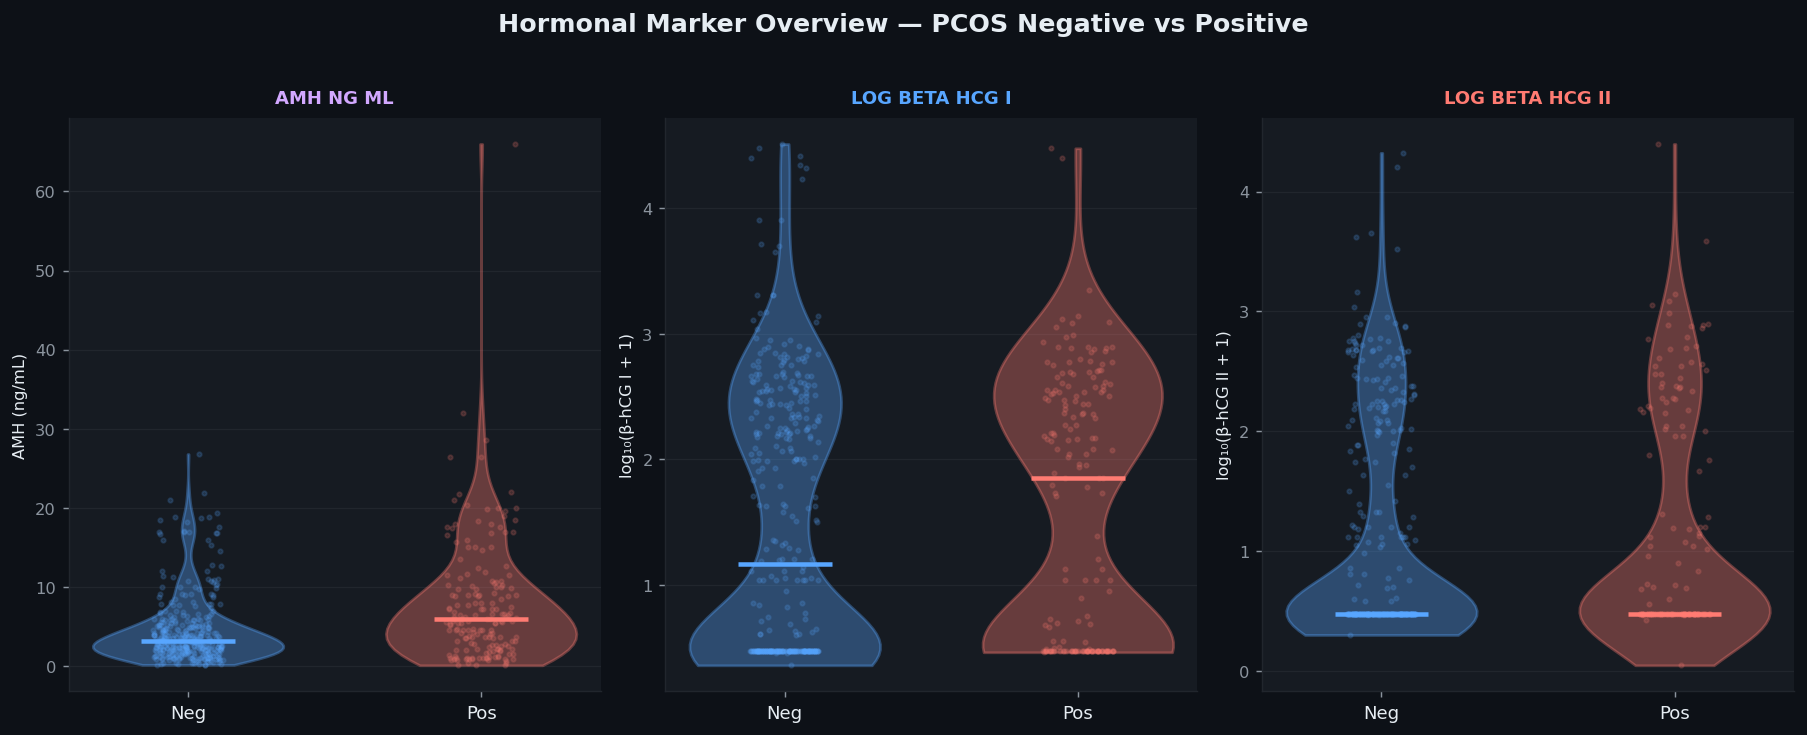

In [24]:
# ── Summary: 3-panel violin grid for all markers ─────────────────────────────
marker_configs = [
    ("amh_ng_ml",          "AMH (ng/mL)",        ACCENT_D),
    ("log_beta_hcg_i",     "log₁₀(β-hCG I + 1)", ACCENT_A),
    ("log_beta_hcg_ii",    "log₁₀(β-hCG II + 1)",ACCENT_B),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 5.5))

for ax, (feat, ylabel, accent) in zip(axes, marker_configs):
    data_neg = df.loc[df.pcos_label == "PCOS Negative", feat].dropna()
    data_pos = df.loc[df.pcos_label == "PCOS Positive",  feat].dropna()

    parts = ax.violinplot(
        [data_neg, data_pos], positions=[0, 1],
        widths=0.65, showmedians=False, showextrema=False,
    )
    vcolors = [ACCENT_A, ACCENT_B]
    for pc, clr in zip(parts["bodies"], vcolors):
        pc.set_facecolor(clr); pc.set_alpha(0.35)
        pc.set_edgecolor(clr); pc.set_linewidth(1.5)

    # Median lines
    for i, (vals, clr) in enumerate(zip([data_neg, data_pos], vcolors)):
        ax.hlines(vals.median(), i - 0.16, i + 0.16, color=clr, linewidth=2.5, zorder=5)

    # Jittered dots
    rng = np.random.default_rng(42)
    for i, (vals, clr) in enumerate(zip([data_neg, data_pos], vcolors)):
        jitter = rng.uniform(-0.12, 0.12, len(vals))
        ax.scatter(i + jitter, vals, color=clr, alpha=0.18, s=6, zorder=3)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Neg", "Pos"], color=TEXT_PRI, fontsize=10)
    ax.set_ylabel(ylabel, color=TEXT_PRI, fontsize=9)
    ax.set_title(feat.replace("_", " ").upper(), pad=8,
                 color=accent, fontsize=10, fontweight="bold")
    style_ax(ax, grid_axis="y")

fig.suptitle("Hormonal Marker Overview — PCOS Negative vs Positive",
             fontsize=14, color=TEXT_PRI, fontweight="bold", y=1.02)
plt.tight_layout()
save_figure(fig, "summary_all_markers.png")
plt.show()

---
## Invasive-Feature Usefulness Summary

**Observational summary:** This hormonal side dataset is showing that AMH carries the clearest invasive separation by PCOS status. The beta-HCG markers are highly skewed, overlap heavily between groups, and are strongly redundant with one another, so they do not behave like two independent sources of diagnostic value.

**Simple wrap-up:** In plain language, AMH looks useful, while beta-HCG looks noisy and repetitive.

**Feature usefulness interpretation:**
**Stronger invasive feature:** `amh_ng_ml`
**Use cautiously:** `beta_hcg_i_miu_ml`, `beta_hcg_ii_miu_ml`
**Possible engineering option:** one beta-HCG representative summary only if later evaluation shows added value
**Study positioning:** This file should be treated as a hormonal side dataset of the main clinical cohort, not as an external validation dataset or an independent modelling cohort.
